# Smartphone Usage & Addiction Analysis
**Author:** Aljon Velario Reyes

This notebook walks through a complete machine learning pipeline — from loading raw data to saving a production-ready model — to predict whether a smartphone user shows signs of addiction based on their behavioral patterns.

## Step 1: Data Loading & Initial Inspection

The very first step in any data science project is to load the dataset and take a careful look at its raw form. We inspect the shape (how many rows and columns exist), the column names and their data types, and the first few rows of actual data. This initial inspection tells us what kind of variables we are dealing with (numbers vs. text), reveals obviously missing values, and gives us an intuition for what cleaning will be needed before any analysis can begin. We do not modify the data at all in this step — we only observe.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

# Inspect size and structure
print("Shape:", df.shape)
print("\nColumn Names & Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())
print("\nBasic Statistics:")
display(df.describe())
print("\nMissing Values Per Column:")
print(df.isnull().sum())

Shape: (7500, 16)

Column Names & Types:
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

First 5 Rows:


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1



Basic Statistics:


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000



Missing Values Per Column:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


## Step 2: Data Cleaning & Encoding

Raw data is almost never ready for a machine learning algorithm. This step prepares it in four stages:

**1. Drop leakage and irrelevant columns.** The `addiction_level` column is a multi-class version of our binary target (`addicted_label`). Keeping it would give the model a direct shortcut to the answer — this is called data leakage, and it produces a model that looks perfect in testing but fails completely on real-world data. The `transaction_id` and `user_id` columns are just row identifiers with no predictive meaning, while `age` and `gender` are demographic variables that we have decided to exclude from this behavioral model.

**2. Remove rows with a missing target.** If a row has no `addicted_label`, we cannot learn from it, so it is dropped entirely.

**3. Fill missing values.** For numeric columns we use the median rather than the mean, because the median is not thrown off by extreme outliers (for example, a single user with 20 hours of screen time). For text (categorical) columns we use the mode — the most frequently occurring category — as the best neutral substitute.

**4. Label Encode categorical text.** Machine learning models require every input to be a number. Label Encoding maps each unique text value in a column to a unique integer (for example, `Low` → 0, `Medium` → 1, `High` → 2). This is appropriate here because these columns will feed into a tree-based model that does not assume any mathematical distance between the encoded integers.

In [2]:
from sklearn.preprocessing import LabelEncoder

# 1. Remove leakage columns and identifiers
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level', 'age', 'gender']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Drop rows where the target label is missing
df = df.dropna(subset=['addicted_label'])

# 3. Fill missing values
num_cols = df.select_dtypes(include=np.number).columns.drop('addicted_label')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Encode all remaining categorical columns as integers
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Cleaned Dataset Shape:", df.shape)
print("All columns are now numeric:", df.dtypes.unique())

Cleaned Dataset Shape: (7500, 11)
All columns are now numeric: [dtype('float64') dtype('int64')]


## Step 3: Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to build an intuition for its patterns. EDA is divided into two levels:

**Univariate analysis** looks at one variable at a time. The histogram with a KDE (Kernel Density Estimate) curve shows us the distribution of daily screen time — whether most users cluster around a moderate amount, or whether usage is skewed toward heavy or light users.

**Bivariate analysis** compares two variables simultaneously. The boxplot places addicted users (label = 1) and non-addicted users (label = 0) side by side, making it immediately visible whether addicted users tend to have higher screen time, and whether there is overlap between the two groups.

Finally, the **correlation heatmap** quantifies the linear relationship between every pair of features. Values close to +1 mean the two features rise together; values close to -1 mean one rises as the other falls; values near 0 mean there is little to no linear relationship. We apply a threshold to show only strong correlations (|r| ≥ 0.5), keeping the chart readable and highlighting only the most meaningful relationships.

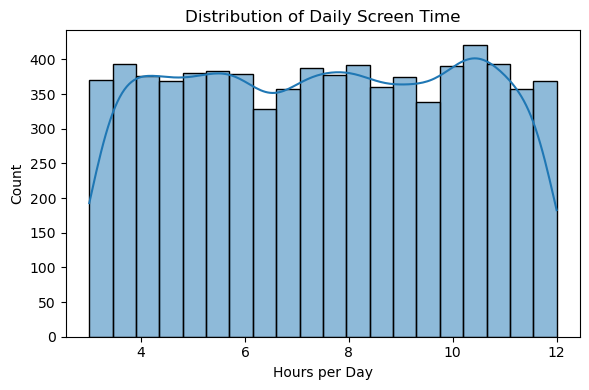

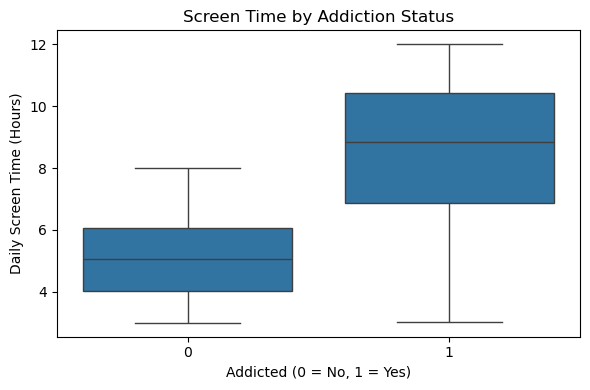

--- Features Highly Correlated with Target (|r| >= 0.5) ---
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
Name: addicted_label, dtype: float64


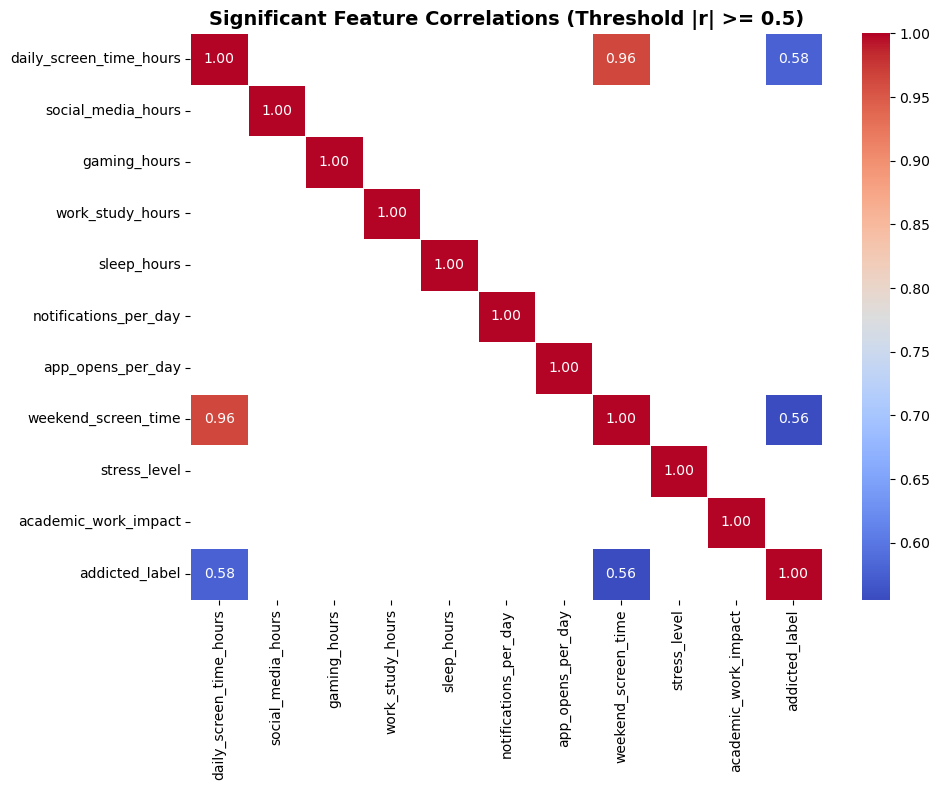

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Univariate Analysis ---
plt.figure(figsize=(6, 4))
sns.histplot(df['daily_screen_time_hours'], kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours per Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Bivariate Analysis ---
plt.figure(figsize=(6, 4))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df)
plt.title("Screen Time by Addiction Status")
plt.xlabel("Addicted (0 = No, 1 = Yes)")
plt.ylabel("Daily Screen Time (Hours)")
plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
corr_matrix = df.corr()
target_corr = corr_matrix['addicted_label'].drop('addicted_label').sort_values(ascending=False)

threshold = 0.5
high_target_corr = target_corr[target_corr.abs() >= threshold]
print(f"--- Features Highly Correlated with Target (|r| >= {threshold}) ---")
if not high_target_corr.empty:
    print(high_target_corr)
else:
    print("No features met the threshold of 0.5 with the target variable.")

plt.figure(figsize=(10, 8))
mask = np.abs(corr_matrix) < threshold
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask,
            cbar=True, fmt=".2f", linewidths=0.5)
plt.title(f"Significant Feature Correlations (Threshold |r| >= {threshold})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering

Individual raw columns often fail to capture the full complexity of human behavior. Feature engineering creates new columns by mathematically combining existing ones, giving the model richer and more context-aware inputs to learn from.

- **`total_usage`** adds daily screen time, social media hours, and gaming hours together to form a single "total digital exposure" metric.
- **`sleep_ratio`** expresses sleep hours as a proportion of a full day, making it easier to compare across users.
- **`risk_ratio`** divides screen time by sleep hours to detect users whose screen use encroaches heavily on their rest (a known addiction indicator). We add 0.1 to the denominator to prevent division by zero.
- **`habit_intensity`** multiplies app opens per day by notifications per day, capturing how actively and frequently the device demands the user's attention.
- **`weekend_spike`** compares weekend screen time to average daily screen time, identifying binge behavior that does not show up in daily averages alone.

These five new columns are added alongside the originals so that the model can choose whether to rely on them or on the raw features.

In [4]:
# Create behavioral context features
df['total_usage']       = df['daily_screen_time_hours'] + df['social_media_hours'] + df['gaming_hours']
df['sleep_ratio']       = df['sleep_hours'] / 24.0
df['risk_ratio']        = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1)
df['habit_intensity']   = df['app_opens_per_day'] * df['notifications_per_day']
df['weekend_spike']     = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 0.1)

print("Engineered features added. New shape:", df.shape)
print("New columns:", ['total_us'
'age', 'sleep_ratio', 'risk_ratio', 'habit_intensity', 'weekend_spike'])

Engineered features added. New shape: (7500, 16)
New columns: ['total_usage', 'sleep_ratio', 'risk_ratio', 'habit_intensity', 'weekend_spike']


## Step 5: Train-Test Split & Feature Scaling

Before training any model, we must set aside a portion of the data that the model will never see during training. This held-out set is used only at the very end to measure how well the model generalizes to genuinely new data.

We split 80% of the data into the **Training Set** (what the model learns from) and hold back 20% as the **Test Set** (the final exam it has never studied). The `stratify=y` argument ensures the ratio of addicted to non-addicted users is identical in both halves — without this, a random split could accidentally put nearly all addicted users in one set, making evaluation unfair.

**StandardScaler** then transforms each feature so it has a mean of 0 and a standard deviation of 1. This is essential because features measured on very different scales — for example, `notifications_per_day` might range in the hundreds while `sleep_ratio` sits between 0 and 1 — can cause gradient-based and distance-based algorithms to over-weight the larger-scale features. Critically, we call `fit_transform` only on the training data, then apply the same learned parameters with `transform` to the test data. Fitting the scaler on the test data would introduce future information into the training process, invalidating the evaluation.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate inputs from the target
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale: fit only on training data, then apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set size : {X_train_scaled.shape}")
print(f"Test set size     : {X_test_scaled.shape}")

Training set size : (6000, 15)
Test set size     : (1500, 15)


## Step 6: Baseline Model Comparison

Rather than committing to one algorithm upfront, we run six different classifiers on the same training data and measure how each performs on the unseen test set. This gives us a fair, side-by-side competition before we invest time in fine-tuning.

The six models span a wide range of complexity and approach: Logistic Regression is a simple linear boundary; Support Vector Machine (SVM) finds the maximum-margin hyperplane; K-Nearest Neighbors (KNN) classifies by majority vote among nearby data points; Decision Tree builds a sequence of if-else rules; Random Forest and Gradient Boosting are ensemble methods that combine hundreds of trees to capture non-linear, nuanced patterns in the data.

We expect the ensemble methods to lead the leaderboard here, because addiction-related behavior tends to involve complex interactions between features (for example, the combination of a high weekend spike and high habit intensity) rather than simple linear thresholds. The top performer will be selected for hyperparameter tuning in the next step.

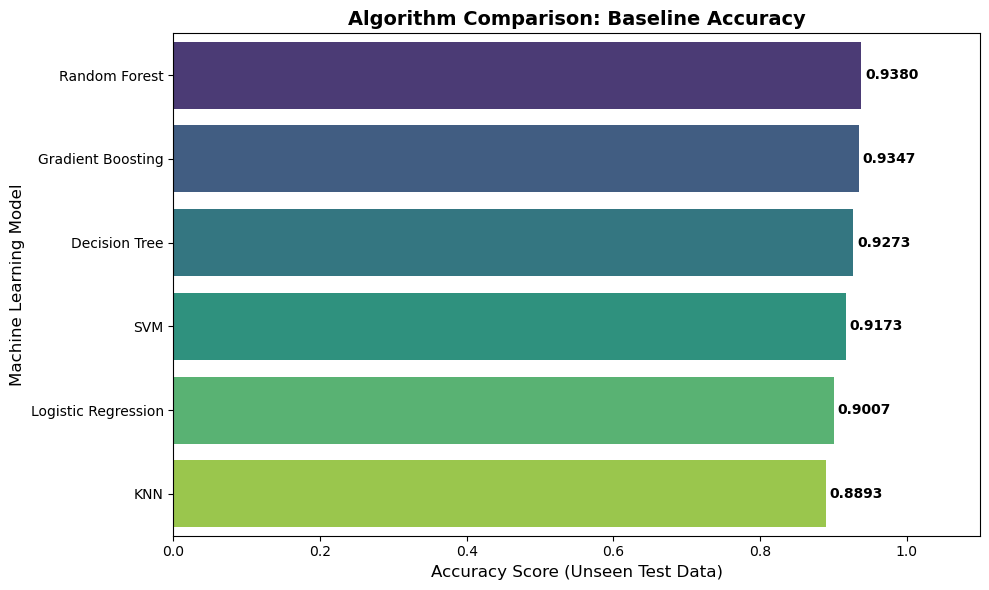

                 Model  Accuracy
4        Random Forest  0.938000
5    Gradient Boosting  0.934667
3        Decision Tree  0.927333
1                  SVM  0.917333
0  Logistic Regression  0.900667
2                  KNN  0.889333


In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression'  : LogisticRegression(random_state=42),
    'SVM'                  : SVC(random_state=42),
    'KNN'                  : KNeighborsClassifier(),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest'        : RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(
    by='Accuracy', ascending=False
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.005, index, f"{value:.4f}", va='center', fontweight='bold')
plt.title('Algorithm Comparison: Baseline Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score (Unseen Test Data)', fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

print(results_df)

## Step 7: Hyperparameter Tuning (GridSearchCV)

Every model has internal settings called **hyperparameters** — values the programmer sets before training begins, as opposed to the weights the model learns from the data itself. Choosing these values wisely can significantly improve performance.

**GridSearchCV** automates this by testing every combination of values we specify in a grid. For Random Forest we tune three key hyperparameters:
- `n_estimators` controls how many decision trees are grown in the forest. More trees generally mean better accuracy but longer training time.
- `max_depth` limits how deep each tree can grow. A shallow tree is simple and may underfit; a very deep tree memorizes training data and may overfit.
- `min_samples_split` sets the minimum number of data points required before a node in a tree can be split further. Higher values prevent trees from making overly specific rules.

To evaluate each combination fairly, GridSearchCV uses **5-fold cross-validation**: it divides the training data into 5 equal parts, trains on 4 of them, and validates on the remaining 1, cycling through all 5 permutations. The combination that achieves the highest average validation accuracy across all 5 folds is selected as the winner.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [3, 4, 5],       # Removed None — unlimited depth causes overfitting
    'min_samples_split': [2, 5, 10]
}

print("Starting Grid Search... this may take a moment.")

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

print("\n--- Hyperparameter Tuning Complete ---")
print("Best Parameters Found :", grid_search.best_params_)
print(f"Best CV Accuracy      : {grid_search.best_score_ * 100:.2f}%")

Starting Grid Search... this may take a moment.

--- Hyperparameter Tuning Complete ---
Best Parameters Found : {'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy      : 93.62%


## Step 8: Final Model Evaluation (Confusion Matrix & Classification Metrics)

We now evaluate the best model found by GridSearchCV on the completely unseen test set. The **Confusion Matrix** is the most transparent way to understand exactly where the model succeeds and where it fails. It breaks every prediction into four categories:

- **True Positives (TP):** The model predicted "Addicted" and the user actually was addicted. A correct catch.
- **True Negatives (TN):** The model predicted "Not Addicted" and the user was genuinely safe. A correct clearance.
- **False Positives (FP):** The model predicted "Addicted" but the user was actually safe. A false alarm — the less dangerous of the two error types.
- **False Negatives (FN):** The model predicted "Not Addicted" but the user was actually addicted. A missed case — in a health-screening context this is the most dangerous error, as a real problem goes undetected.

From these four counts we compute the four standard classification metrics:
- **Accuracy** is the percentage of all predictions (both positive and negative) that were correct.
- **Precision** answers: "Of everyone the model flagged as addicted, what fraction truly was?" High precision means few false alarms.
- **Recall** answers: "Of everyone who was truly addicted, what fraction did the model successfully catch?" High recall means few missed cases.
- **F1 Score** is the harmonic mean of Precision and Recall. It is the preferred single-number summary when false negatives carry higher cost than false positives, because it penalizes models that sacrifice one metric to inflate the other.

--- CONFUSION MATRIX BREAKDOWN ---
True Positives  (TP) - Correctly identified addicted users : 981
True Negatives  (TN) - Correctly cleared safe users        : 429
False Positives (FP) - Safe users wrongly flagged          : 9
False Negatives (FN) - Addicted users the model missed     : 81

--- CLASSIFICATION METRICS ---
Accuracy  : 0.9400
Precision : 0.9909  (When it flags addiction, it is correct 99.1% of the time)
Recall    : 0.9237  (It caught 92.4% of all truly addicted users)
F1 Score  : 0.9561  (Balanced measure of Precision and Recall)


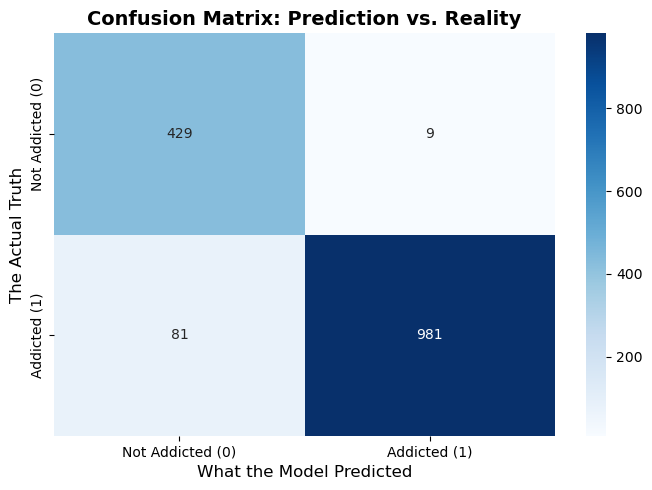

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions with the tuned model
y_pred = best_model.predict(X_test_scaled)

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Classification metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("--- CONFUSION MATRIX BREAKDOWN ---")
print(f"True Positives  (TP) - Correctly identified addicted users : {tp}")
print(f"True Negatives  (TN) - Correctly cleared safe users        : {tn}")
print(f"False Positives (FP) - Safe users wrongly flagged          : {fp}")
print(f"False Negatives (FN) - Addicted users the model missed     : {fn}")

print("\n--- CLASSIFICATION METRICS ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}  (When it flags addiction, it is correct {precision*100:.1f}% of the time)")
print(f"Recall    : {recall:.4f}  (It caught {recall*100:.1f}% of all truly addicted users)")
print(f"F1 Score  : {f1:.4f}  (Balanced measure of Precision and Recall)")

# Visual confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Addicted (0)', 'Addicted (1)'],
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])
plt.title('Confusion Matrix: Prediction vs. Reality', fontsize=14, fontweight='bold')
plt.xlabel('What the Model Predicted', fontsize=12)
plt.ylabel('The Actual Truth', fontsize=12)
plt.tight_layout()
plt.show()

## Step 9: Feature Importance

Knowing that a model is accurate is useful, but understanding **why** it makes its decisions is what turns a black box into an actionable tool — especially when presenting findings to stakeholders or a professor.

A Random Forest measures feature importance by tracking, across every split in every tree, how much that split reduced **Gini impurity** (the degree of disorder or uncertainty in a node). Features that consistently produce the cleanest splits — separating addicted from non-addicted users most clearly — receive the highest importance scores. Averaging these contributions across all trees in the forest produces a stable, interpretable ranking.

The bar chart below ranks all features from most to least important, directly answering the question: "Which behaviors are the strongest predictors of smartphone addiction in this dataset?"

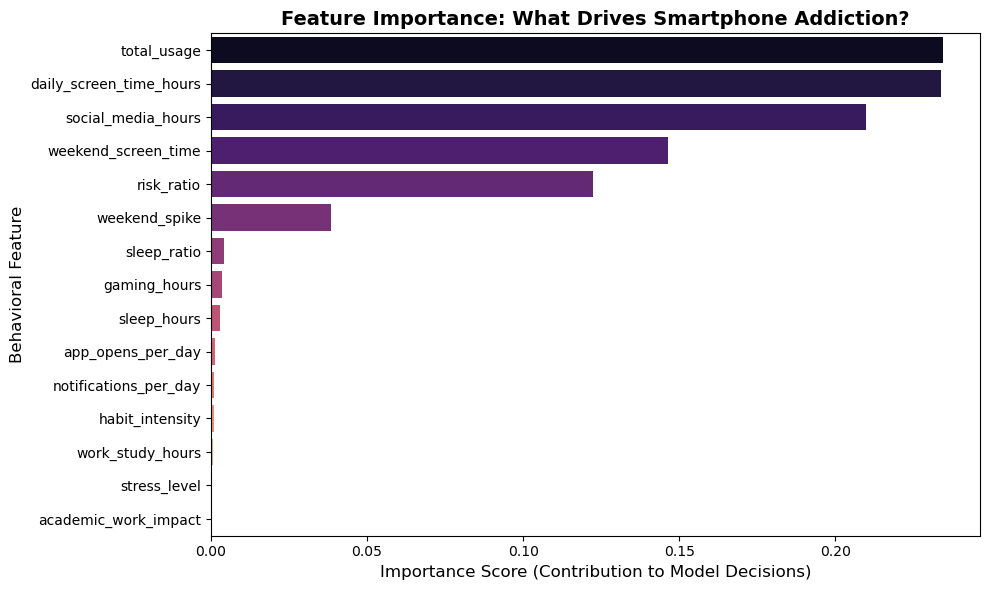

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances   = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance: What Drives Smartphone Addiction?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Model Decisions)', fontsize=12)
plt.ylabel('Behavioral Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Step 10: Validation Curve (Bias-Variance Tradeoff)

The Validation Curve diagnoses one of the most fundamental challenges in machine learning: the **bias-variance tradeoff**.

- **High Bias (Underfitting):** When `max_depth` is very small (shallow trees), the model is too simple to capture the real patterns in the data. Both the training accuracy and the cross-validation accuracy are low. The model has not learned enough.
- **High Variance (Overfitting):** When `max_depth` is very large (very deep trees), the model memorizes the training data perfectly but fails to generalize. Training accuracy approaches 100%, but the gap between training accuracy and cross-validation accuracy widens dramatically.
- **Sweet Spot:** The ideal `max_depth` is the point where cross-validation accuracy peaks before the gap starts to grow. This is the depth at which the model has learned real, generalizable patterns without memorizing noise.

The vertical dashed red line marks the `max_depth` chosen by our GridSearchCV in the previous step. If it sits at or near the peak of the cross-validation curve, it confirms that our tuning process correctly identified the optimal complexity for this dataset.

  STEP 10: VALIDATION CURVE — BIAS VS. VARIANCE TRADEOFF

What we are doing:
  We are training a Random Forest 5 separate times,
  each time increasing the max_depth from 1 to 5.
  For each depth, 5-fold cross-validation is used,
  so the model is actually trained 25 times in total.
  This lets us see exactly how complexity affects
  both training accuracy and generalization accuracy.

Calculating Validation Curve... this may take a minute.
Calculation complete!

-------------------------------------------------------
  Depth       Train Acc       CV Acc        Gap
-------------------------------------------------------
  1              0.8599       0.8592     0.0008
  2              0.8746       0.8718     0.0028
  3              0.9374       0.9335     0.0039
  4              0.9402       0.9357     0.0045
  5              0.9422       0.9352     0.0071
-------------------------------------------------------

How to read this table:
  Train Acc  — How well the model fits the data it 

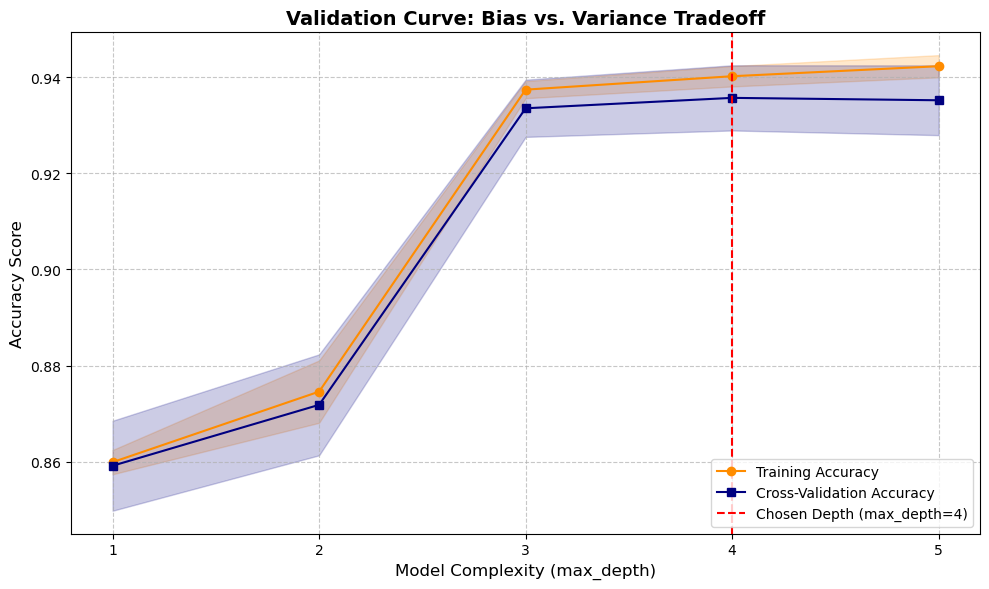


  FINAL MODEL FITNESS SUMMARY
  Training Accuracy : 0.9380  (93.80%)
  Test Accuracy     : 0.9400  (94.00%)
  Gap               : -0.0020  (-0.20%)

  Verdict: WELL-FITTED
  The gap between training and test accuracy is very small.
  The model generalizes well and is neither underfitting
  nor overfitting the data.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

param_range = np.arange(1, 6)  # Depth 1 to 5 only

print("=" * 60)
print("  STEP 10: VALIDATION CURVE — BIAS VS. VARIANCE TRADEOFF")
print("=" * 60)
print()
print("What we are doing:")
print("  We are training a Random Forest 5 separate times,")
print("  each time increasing the max_depth from 1 to 5.")
print("  For each depth, 5-fold cross-validation is used,")
print("  so the model is actually trained 25 times in total.")
print("  This lets us see exactly how complexity affects")
print("  both training accuracy and generalization accuracy.")
print()
print("Calculating Validation Curve... this may take a minute.")

train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_train_scaled, y_train,
    param_name  = "max_depth",
    param_range = param_range,
    cv          = 5,
    scoring     = "accuracy",
    n_jobs      = -1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
test_mean  = np.mean(test_scores,  axis=1)
test_std   = np.std(test_scores,   axis=1)

print("Calculation complete!")
print()

# --- Print the full accuracy table ---
print("-" * 55)
print(f"  {'Depth':<8} {'Train Acc':>12} {'CV Acc':>12} {'Gap':>10}")
print("-" * 55)
for i, depth in enumerate(param_range):
    gap = train_mean[i] - test_mean[i]
    print(f"  {depth:<8} {train_mean[i]:>12.4f} {test_mean[i]:>12.4f} {gap:>10.4f}")
print("-" * 55)
print()
print("How to read this table:")
print("  Train Acc  — How well the model fits the data it was trained on.")
print("  CV Acc     — How well it generalizes to data it has NOT seen.")
print("  Gap        — The difference between the two. A large and")
print("               growing gap is the warning sign of overfitting.")
print()

# --- Identify key depths ---
best_cv_depth = param_range[np.argmax(test_mean)]
best_cv_acc   = np.max(test_mean)

print(f"  Peak CV Accuracy : {best_cv_acc:.4f}  at max_depth = {best_cv_depth}")
print(f"  This is the sweet spot — the depth where the model has")
print(f"  learned real patterns without memorizing noise.")
print()

# --- Determine the best depth from GridSearchCV ---
best_depth = grid_search.best_params_.get('max_depth', 5)
if best_depth is None or best_depth > 5:
    best_depth = 5  # Cap at 5 to stay within our visible range

print(f"  GridSearchCV chose : max_depth = {best_depth}")

if best_depth == best_cv_depth:
    print(f"  This matches the peak CV depth exactly — excellent tuning!")
elif abs(best_depth - best_cv_depth) <= 1:
    print(f"  This is very close to the peak CV depth ({best_cv_depth}).")
    print(f"  The small difference is acceptable and may reflect")
    print(f"  slight variation across the cross-validation folds.")
else:
    print(f"  Note: This differs from the peak CV depth ({best_cv_depth}).")
    print(f"  GridSearchCV used a different scoring breakdown across")
    print(f"  folds, which can occasionally shift the chosen depth.")
print()

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.title("Validation Curve: Bias vs. Variance Tradeoff", fontsize=14, fontweight='bold')
plt.xlabel("Model Complexity (max_depth)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

plt.plot(param_range, train_mean, label="Training Accuracy",        color="darkorange", marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")

plt.plot(param_range, test_mean, label="Cross-Validation Accuracy", color="navy",       marker='s')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Chosen Depth (max_depth={best_depth})')
plt.xticks(param_range)  # Show only depths 1-5 on the x-axis
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Final training accuracy check ---
train_acc = best_model.score(X_train_scaled, y_train)
test_acc  = best_model.score(X_test_scaled,  y_test)
gap       = train_acc - test_acc

print()
print("=" * 60)
print("  FINAL MODEL FITNESS SUMMARY")
print("=" * 60)
print(f"  Training Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Gap               : {gap:.4f}  ({gap*100:.2f}%)")
print()

if gap < 0.03:
    print("  Verdict: WELL-FITTED")
    print("  The gap between training and test accuracy is very small.")
    print("  The model generalizes well and is neither underfitting")
    print("  nor overfitting the data.")
elif gap < 0.07:
    print("  Verdict: SLIGHT OVERFITTING")
    print("  The model performs noticeably better on training data")
    print("  than on the test set. This is within a tolerable range,")
    print("  but reducing max_depth slightly could close the gap.")
else:
    print("  Verdict: OVERFITTING DETECTED")
    print("  The large gap means the model has memorized the training")
    print("  data rather than learning generalizable patterns.")
    print("  Consider reducing max_depth or increasing min_samples_split.")
print("=" * 60)

## Step 11: Saving the Model

Once we are satisfied with the model's performance, we **serialize** it to disk — meaning we convert the trained Python object into a file that can be stored and reloaded later. We use `joblib`, which is the recommended library for saving scikit-learn models because it handles large NumPy arrays (like the many trees inside a Random Forest) far more efficiently than Python's built-in `pickle`.

Crucially, we save **both** the trained model and the fitted **scaler** as separate files. This is not optional — it is a requirement for correct deployment. Any new user data submitted for prediction must pass through the exact same scaling transformation that the training data did. The scaler remembers the mean and standard deviation it computed from the training set; applying those same values to new data ensures the features are on the same numerical scale the model was trained to expect. Without the saved scaler, predictions on new data would be meaningless.

In [5]:
import joblib

# Save the trained model
joblib.dump(best_model, 'smartphone_addiction_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler_v1.pkl')

print("--- SAVING COMPLETE ---")
print("Files saved:")
print("  smartphone_addiction_model.pkl")
print("  scaler_v1.pkl")

# Verify the saves by reloading
loaded_model = joblib.load('smartphone_addiction_model.pkl')
loaded_scaler = joblib.load('scaler_v1.pkl')

verify_pred = loaded_model.predict(loaded_scaler.transform(X_test.iloc[:5]))

print("\nVerification — sample predictions:", verify_pred)
print("Model and Scaler are saved correctly and ready for deployment.")

NameError: name 'best_model' is not defined